In [2]:
using Pkg
Pkg.activate("../")
using Suppressor
@suppress begin
    using Oceananigans, CairoMakie, TimestepperTestCases, Statistics
    using LaTeXStrings, Statistics
end

  Activating project at `~/development/TimestepperTestCases.jl`


In [3]:
# ============================================================================================
# The six time-stepping variants from internal_tide/test.jl, in canonical order.
# `free_surface` is the runner's `free_surface_name` (AB2 uses the default "split_free_surface").
# File loaded: folder * "internal_tide_" * timestepper * "_" * free_surface * ".jld2".
# Update `folder` to wherever the runs wrote their output (the runs are pending).
# ============================================================================================
folder = "../internal_tide/"

# Derived from the package so the notebook cannot drift from the runners.
variants = [(; label = d.label, timestepper = string(d.timestepper), free_surface = d.label) for d in discretizations()]

labels     = [v.label for v in variants]
styles     = [plot_style(v.label) for v in variants]
colors     = [s.color     for s in styles]
linestyles = [s.linestyle for s in styles]
cases  = [@suppress TimestepperTestCases.load_internal_tide(folder, v.timestepper, v.free_surface) for v in variants]

7-element Vector{Dict{Any, Any}}:
 Dict(:b => 256×1×128×961 FieldTimeSeries{OnDisk} located at (Center, Center, Center) of b at ../internal_tide/internal_tide_QuasiAdamsBashforth2_AB2-SE.jld2
├── grid: 256×1×128 ImmersedBoundaryGrid{Float64, Periodic, Flat, Bounded} on CPU with 6×0×6 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: OnDisk
├── path: ../internal_tide/internal_tide_QuasiAdamsBashforth2_AB2-SE.jld2
└── name: b, :Gbx => 256×1×128×961 FieldTimeSeries{InMemory} located at (Face, Center, Center) of Gbx at ../internal_tide/internal_tide_QuasiAdamsBashforth2_AB2-SE.jld2
├── grid: 256×1×128 ImmersedBoundaryGrid{Float64, Periodic, Flat, Bounded} on CPU with 6×0×6 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: InMemory()
├── path: ../internal_tide/internal_tide_QuasiAdamsBashforth2_AB2-SE.jld2
├── name: Gbx
└── data: 268×1×140×961 OffsetArray(::Array{Float64, 4}, -5:262, 1:1, -5:134, 1:961) with eltype Float64 with indices -5:262×1:1×-5:134

In [4]:
using LaTeXStrings

ticks(vec) = (vec, latexstring.(string.(vec)))

function running_mean(v, points)
    n  = length(v)
    rm = zeros(length(v) - 2points+1)
    for i in points+1:n-points
        rm[i-points] = mean(v[i - points:i+points])
    end
    return rm[1:end-1]
end

path = "/Users/simonesilvestri/MIT Dropbox/Simone Silvestri/Apps/Overleaf/timestepper/"

"/Users/simonesilvestri/MIT Dropbox/Simone Silvestri/Apps/Overleaf/timestepper/"

In [5]:
# end-state fields for the snapshot figure, one entry per variant
uprime = [Field(c[:u][end] / c[:VFCC][end] - mean(c[:u][end] / c[:VFCC][end])) for c in cases]
ηend   = [c[:η][end] for c in cases]
N2end  = [Field(∂z(c[:b][end] / c[:VCCC][end])) for c in cases]

bu = Float64.(interior(cases[1][:u][end]) .== 0); bu[bu .== 1] .= NaN
bw = Float64.(interior(N2end[1]) .== 0);          bw[bw .== 1] .= NaN
nothing


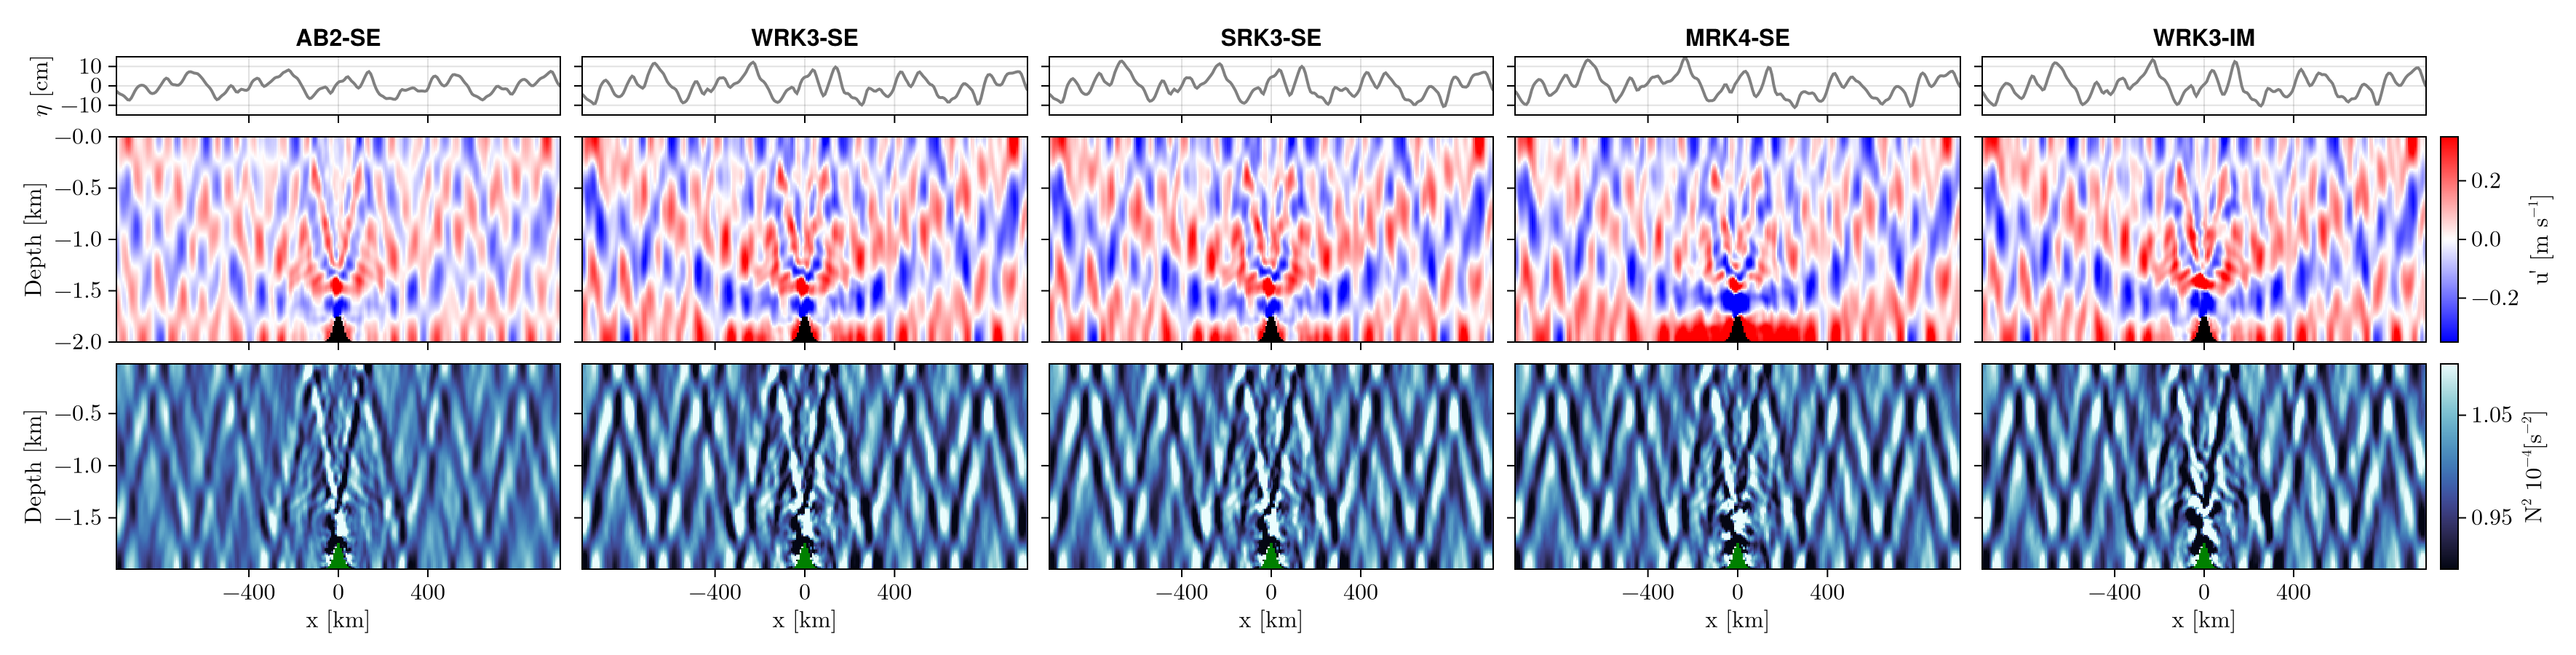

CairoMakie.Screen{PDF}


In [6]:
xu, yu, zu = nodes(cases[1][:u])
xw, yw, zw = nodes(cases[1][:w])
xη, yη, zη = nodes(cases[1][:η])

# Only the cases that differ. WRK3-SE-SM05, SRK3-SE and MRK4-SE are indistinguishable from WRK3-SE,
# which Figure diffusivity-hovmoller establishes quantitatively.
shown = [findfirst(v -> v.label == l, variants) for l in ("AB2-SE", "WRK3-SE", "SRK3-SE", "MRK4-SE", "WRK3-IM")]
xhalf = maximum(xu)
xt  = [-400, 0, 400]
xticks   = (xt .* 1000, latexstring.(string.(xt)))
xnticks  = (xt .* 1000, fill("", length(xt)))
yticks   = ([-2, -1.5, -1, -0.5, -0] .* 1000, latexstring.(string.([-2.0, -1.5, -1.0, -0.5, -0.0])))
ynticks  = ([-2, -1.5, -1, -0.5, -0] .* 1000, ["", "", "", "", ""])
yeticks  = ([-1, -0, 1] .* 1e-1, latexstring.(string.([-10, 0, 10])))
yenticks = ([-1, -0, 1] .* 1e-1, ["", "", ""])

nc  = length(shown)
fig = Figure(size = (330 * nc + 120, 450), fontsize = 16)
ga  = GridLayout(fig[1, 1])

hmu = nothing
hmN = nothing
for (j, k) in enumerate(shown)
    fst = j == 1
    axη = Axis(ga[1, j],   title = variants[k].label, ylabel = fst ? L"\eta \text{ [cm]}"  : "", xticks = xnticks, yticks = fst ? yeticks : yenticks)
    axu = Axis(ga[2:4, j], ylabel = fst ? L"\text{Depth [km]}" : "", xticks = xnticks, yticks = fst ? yticks : ynticks)
    axN = Axis(ga[5:7, j], xlabel = L"\text{x [km]}", ylabel = fst ? L"\text{Depth [km]}" : "", xticks = xticks, yticks = fst ? yticks : ynticks)

    lines!(axη, xη, interior(ηend[k], :, 1, 1), color = :grey, linewidth = 2)
    ylims!(axη, -0.15, 0.15)

    global hmu = heatmap!(axu, xu, zu, interior(uprime[k], :, 1, :) .+ bu[:, 1, :]; colormap = :bwr, colorrange = (-0.35, 0.35), nan_color = :black)
    global hmN = heatmap!(axN, xw, zw[2:127], interior(N2end[k], :, 1, 2:127) .+ bw[:, 1, 2:127]; colormap = :ice, colorrange = (0.00009, 0.00011), nan_color = :green)

    for ax in (axη, axu, axN); xlims!(ax, -xhalf, xhalf); end
end
Colorbar(ga[2:4, nc+1], hmu, label = L"\text{u' [m s}^{-1}\text{]}", ticks = ([-0.2, 0.0, 0.2], latexstring.(string.([-0.2, 0.0, 0.2]))))
Colorbar(ga[5:7, nc+1], hmN, label = L"\text{N}^{2}\text{ } 10^{-4}\text{[s}^{-2}\text{]}", ticks = ([0.95, 0.00, 1.05] .* 1e-4, latexstring.(string.([0.95, 0.00, 1.05]))))

colgap!(ga, 10); rowgap!(ga, 10)
display(fig)
CairoMakie.save(path * "figure-internal-tide.pdf", fig)

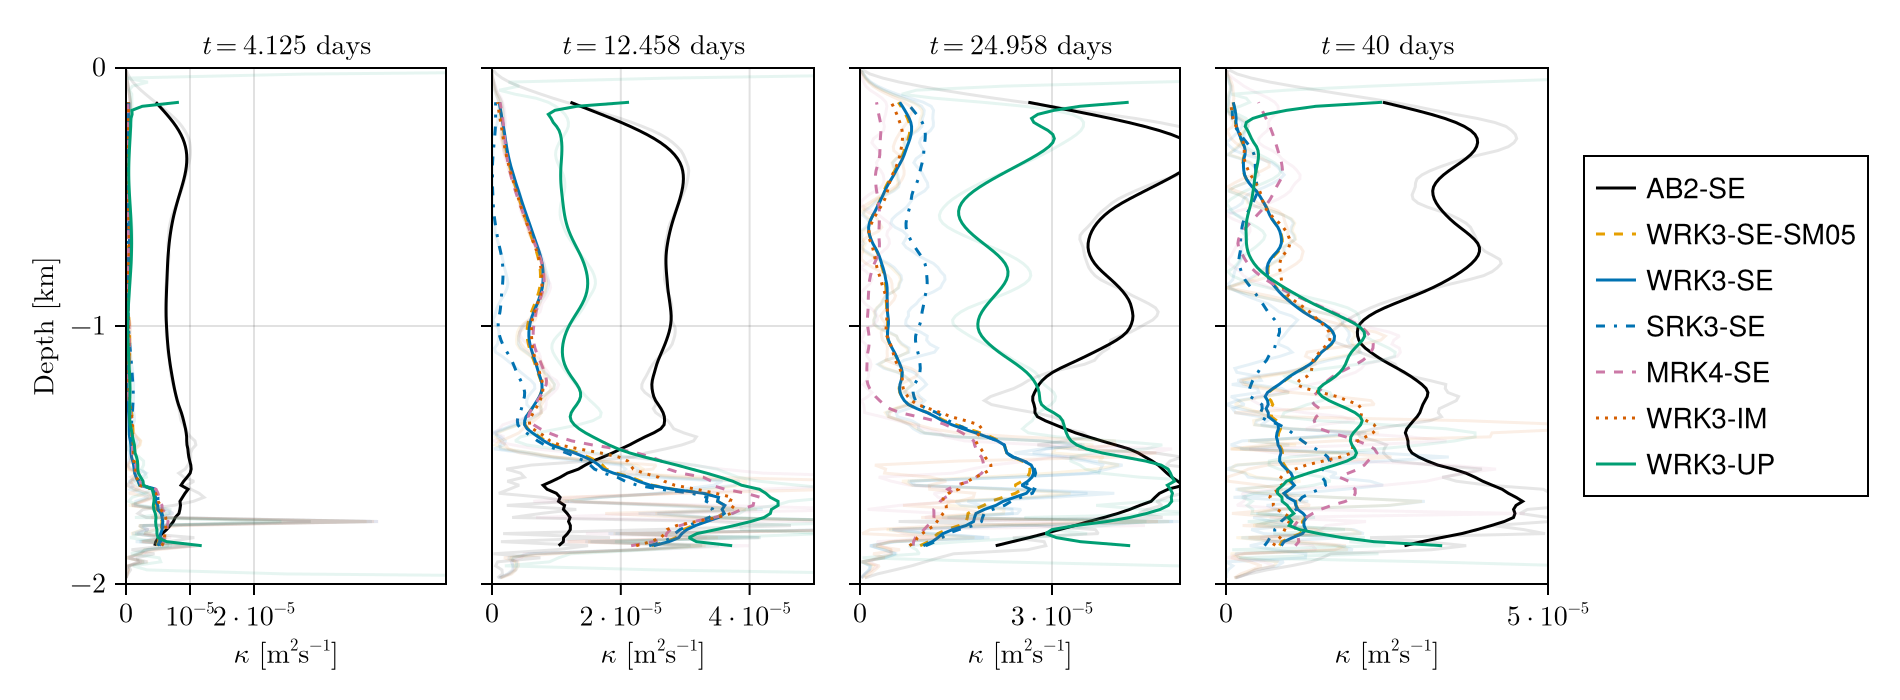

CairoMakie.Screen{PDF}


In [7]:
mvv = 8
zC  = cases[1][:Abx].grid.z.cᵃᵃᶜ[2:128] ./ 1000
fig = Figure(size = (950, 350))

xticks_list = [
    ([0, 1e-5, 2e-5],         [L"0", L"10^{-5}", L"2 \cdot 10^{-5}"]),
    ([0, 2e-5, 4e-5, 6e-5],   [L"0", L"2\cdot 10^{-5}", L"4 \cdot 10^{-5}", L"6 \cdot 10^{-5}"]),
    ([0, 3e-5, 6e-5, 9e-5],   [L"0", L"3\cdot 10^{-5}", L"6 \cdot 10^{-5}", L"9 \cdot 10^{-5}"]),
    ([0, 5e-5, 1e-4, 1.5e-4], [L"0", L"5\cdot 10^{-5}", L"10^{-4}", L"1.5 \cdot 10^{-4}"]),
]
its = [100, 300, 600, 961]
ϵ   = 0

κprofile(c, it) = abs.(interior(Field(mean(c[:Abz][it] + c[:Abx][it], dims=1) / (mean(c[:Gbz][it], dims=1) + ϵ) / 2), 1, 1, 2:128))

axref = nothing
for (col, it) in enumerate(its)
    ax = Axis(fig[1, col];
              xlabel = L"\kappa \text{ [m}^2\text{s}^{-1}\text{]}",
              xticks = xticks_list[col],
              title  = L"t = \text{%$(Oceananigans.Utils.prettytime(cases[1][:Abz].times[it]))}",
              ylabel = col == 1 ? L"\text{Depth [km]}" : "",
              yticks = col == 1 ? ticks([-2, -1, 0]) : ([-2, -1, 0], ["", "", ""]))
    for (i, c) in enumerate(cases[1:end])
        κ = κprofile(c, it)
        lines!(ax, κ, zC, color = (colors[i], 0.1))
        lines!(ax, running_mean(κ, mvv), running_mean(zC, mvv), color = colors[i], linewidth = 1.5, label = labels[i], linestyle = linestyles[i])
    end
    ylims!(ax, -2, 0)
    xlims!(ax, 0, 5e-5)
    if col == 1; global axref = ax; end
end
Legend(fig[1, 5], axref)
display(current_figure())
CairoMakie.save(path * "diffusivity-internal-tide.pdf", fig)


## Hovmöller of the numerical diffusivity
κ(z, t), x-averaged, one row per case. Costs one reduction per output time per case (~960 × 7 here),
so subsample with `itr = 1:2:…` if it is slow.


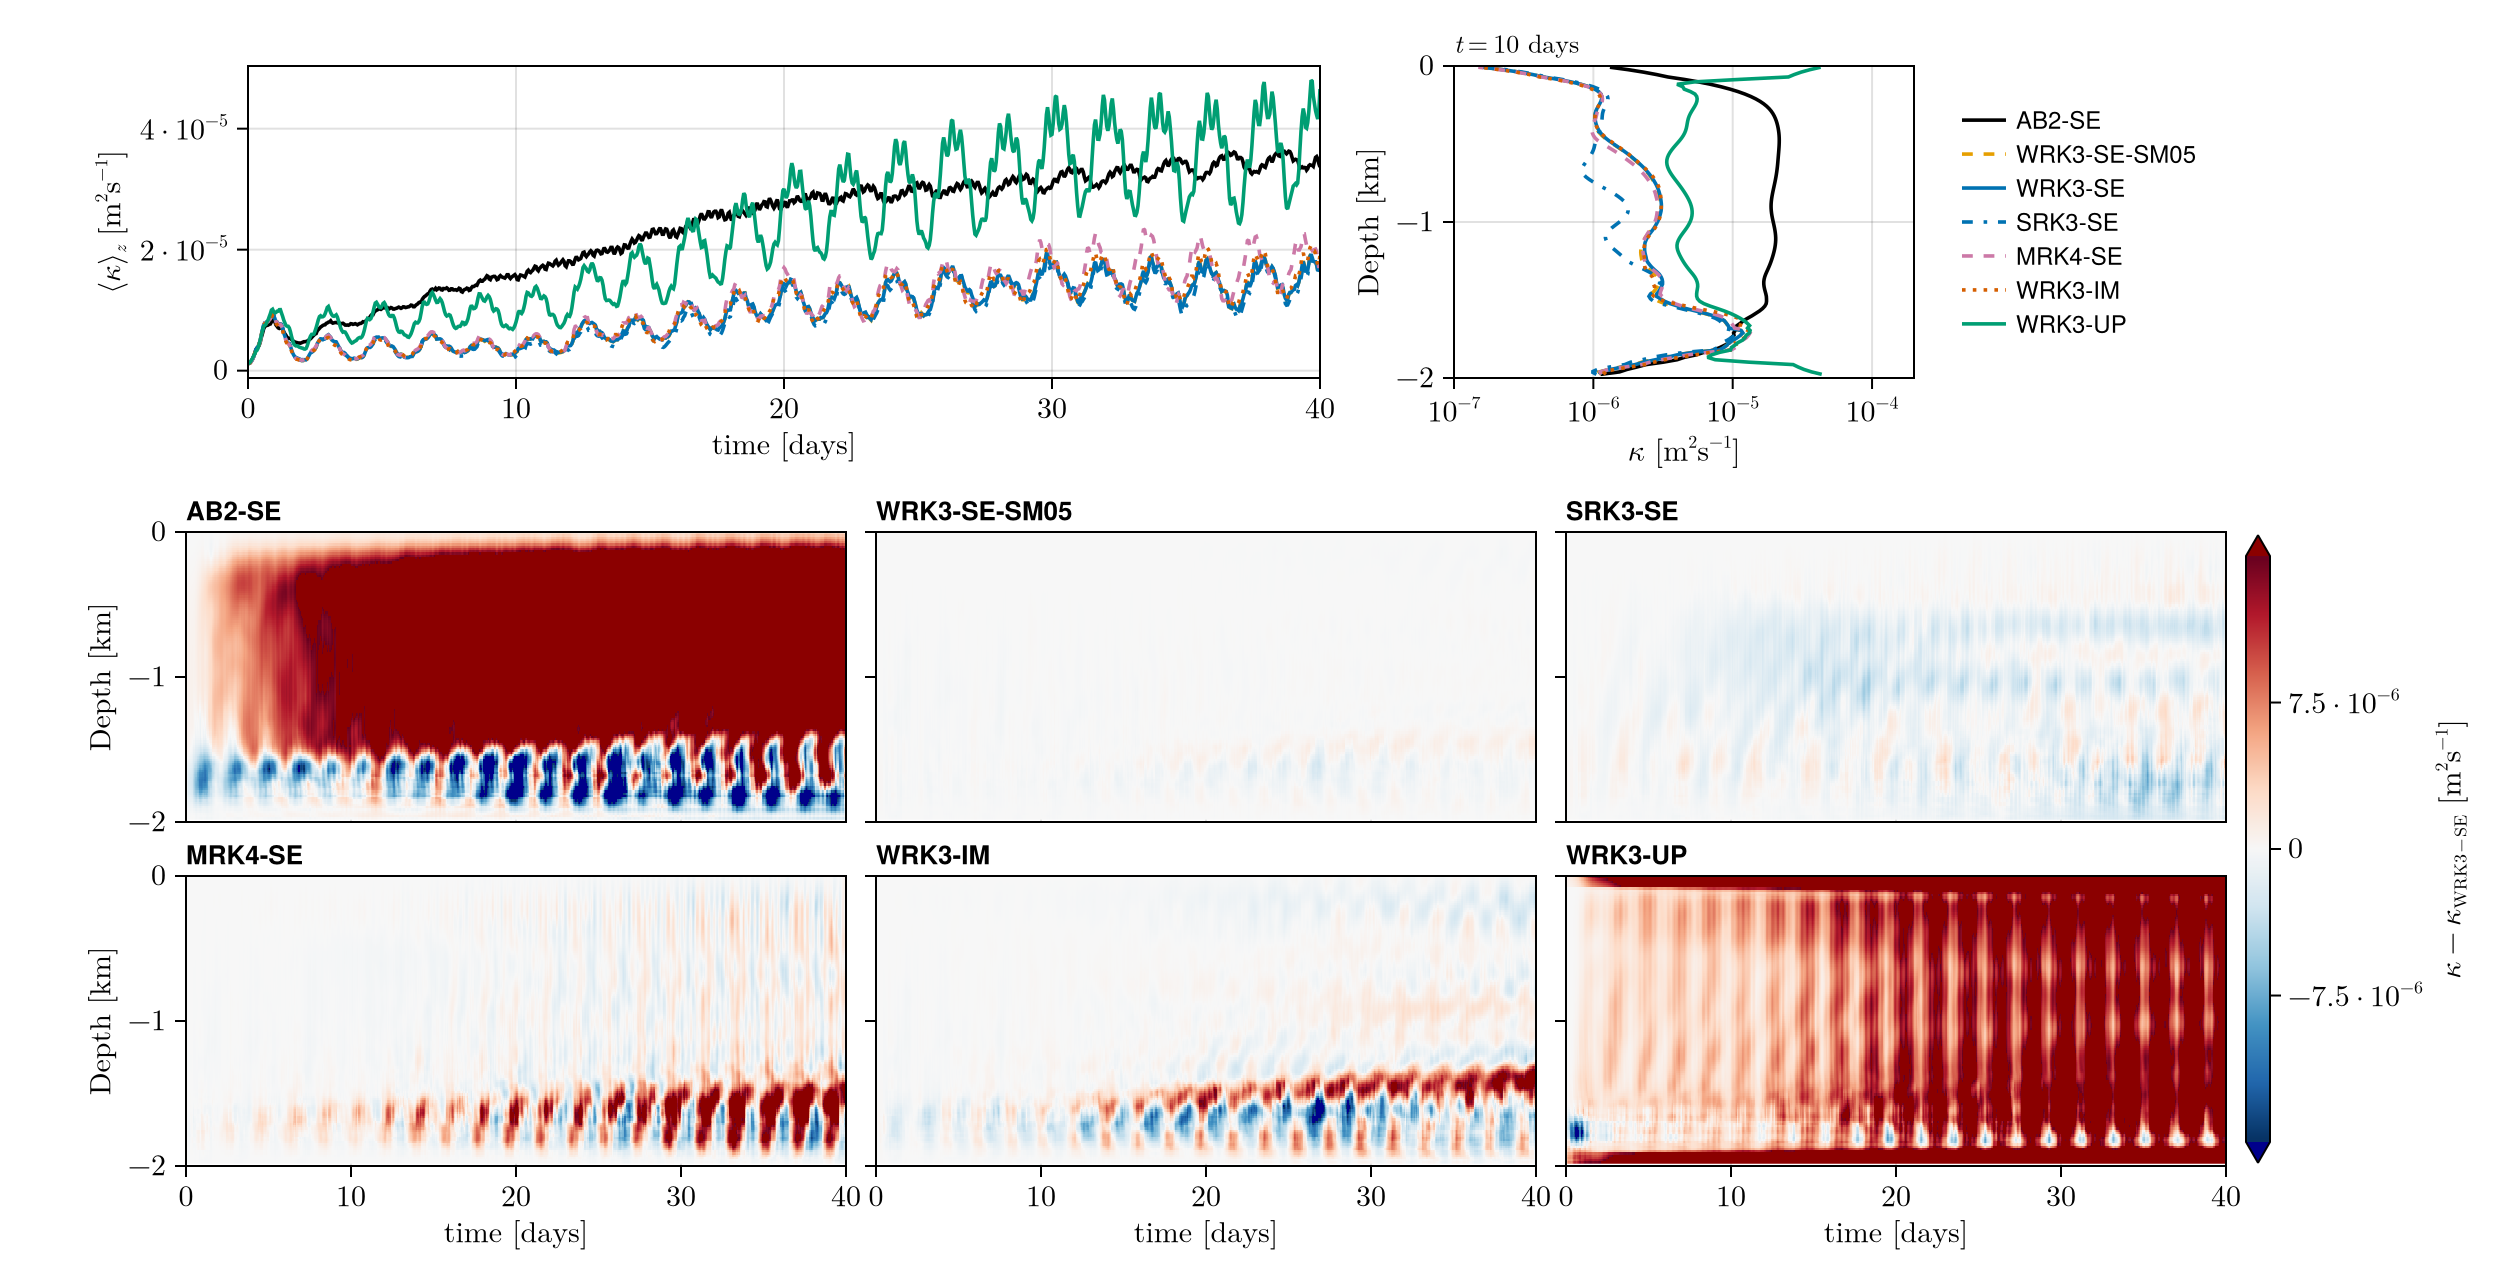

CairoMakie.Screen{PDF}


In [8]:
difference = true
ϵκ         = 1e-3 * 1e-4
nz_win     = 4
nt_win     = 6
ncols      = 3
t_profile  = 10
κfloor     = 1e-9
κmax       = 1.5e-5      # colour saturation; raise to desaturate further

itr   = 1:length(cases[1][:Abz].times)
tdays = cases[1][:Abz].times[itr] ./ 86400

κprof(c, it) = abs.(interior(Field(mean(c[:Abz][it] + c[:Abx][it], dims=1) /
                                   (mean(c[:Gbz][it], dims=1) + ϵκ) / 2), 1, 1, 2:128))

function boxmean(A, nz, nt)
    nzA, ntA = size(A)
    B = similar(A)
    for j in 1:ntA, i in 1:nzA
        B[i, j] = mean(@view A[max(1, i-nz):min(nzA, i+nz), max(1, j-nt):min(ntA, j+nt)])
    end
    return B
end

κs = [boxmean(reduce(hcat, [κprof(c, it) for it in itr]), nz_win, nt_win) for c in cases]

iref   = findfirst(v -> v.label == "WRK3-SE", variants)
panels = difference ? [i for i in eachindex(cases) if i != iref] : collect(eachindex(cases))
fields = difference ? [κs[i] .- κs[iref] for i in panels] : [κs[i] for i in panels]
crange = difference ? (-κmax, κmax) : (0, 4e-5)
cmap   = difference ? Reverse(:RdBu) : :magma

tticks    = ticks([0, 10, 20, 30, 40])
zticks    = ticks([-2, -1, 0])
cbticks   = ([-κmax, -κmax/2, 0.0, κmax/2, κmax],
             [L"-1.5\cdot 10^{-5}", L"-7.5\cdot 10^{-6}", L"0", L"7.5\cdot 10^{-6}", L"1.5\cdot 10^{-5}"])
κticks    = ([0.0, 2e-5, 4e-5, 6e-5], [L"0", L"2\cdot 10^{-5}", L"4\cdot 10^{-5}", L"6\cdot 10^{-5}"])
κlogticks = ([1e-7, 1e-6, 1e-5, 1e-4], [L"10^{-7}", L"10^{-6}", L"10^{-5}", L"10^{-4}"])

nrows = cld(length(panels), ncols)
fig   = Figure(size = (1250, 640), fontsize = 15)

gtop = GridLayout(fig[1, 1])       # independent column sizing, so the log axis cannot
gbot = GridLayout(fig[2, 1])       # push the Hovmöller columns out of alignment

# ── summary row ───────────────────────────────────────────────────────────────────────────────────
it_p = argmin(abs.(tdays .- t_profile))

axg = Axis(gtop[1, 1]; xlabel = L"\text{time [days]}", xticks = tticks, yticks = κticks,
           ylabel = L"\langle \kappa \rangle_z \text{ [m}^2\text{s}^{-1}\text{]}")
axp = Axis(gtop[1, 2]; xlabel = L"\kappa \text{ [m}^2\text{s}^{-1}\text{]}",
           xscale = log10, xticks = κlogticks,
           ylabel = L"\text{Depth [km]}", yticks = zticks,
           title = L"t = %$(t_profile) \text{ days}", titlealign = :left, titlesize = 13)

for (i, c) in enumerate(cases)
    lines!(axg, tdays, vec(mean(κs[i], dims = 1));
           color = colors[i], linestyle = linestyles[i], linewidth = 1.8, label = labels[i])
    lines!(axp, max.(κs[i][:, it_p], κfloor), zC;
           color = colors[i], linestyle = linestyles[i], linewidth = 1.8)
end
xlims!(axg, 0, 40)
ylims!(axp, -2, 0); xlims!(axp, 1e-7, 2e-4)

Legend(gtop[1, 3], axg; framevisible = false, labelsize = 12, patchsize = (22, 12))
colsize!(gtop, 1, Relative(0.56))
colsize!(gtop, 2, Relative(0.24))

# ── Hovmöller panels ──────────────────────────────────────────────────────────────────────────────
hm = nothing
for (r, i) in enumerate(panels)
    row, col = cld(r, ncols), mod1(r, ncols)
    bottom   = r + ncols > length(panels)

    ax = Axis(gbot[row, col]; title = labels[i], titlealign = :left, titlesize = 13, titlegap = 3,
              ylabel = col == 1 ? L"\text{Depth [km]}" : "",
              yticks = col == 1 ? zticks : ([-2, -1, 0], ["", "", ""]),
              xticks = tticks,
              xticksvisible = bottom, xticklabelsvisible = bottom,
              xlabel = bottom ? L"\text{time [days]}" : "")

    global hm = heatmap!(ax, tdays, zC, fields[r]'; colorrange = crange, colormap =  Reverse(:RdBu),
                         lowclip = :darkblue, highclip = :darkred, rasterize = 2)
    ylims!(ax, -2, 0); xlims!(ax, 0, 40)
end

Colorbar(gbot[1:nrows, ncols+1], hm; ticks = cbticks,
         label = difference ? L"\kappa - \kappa_{\text{WRK3-SE}} \text{ [m}^2\text{s}^{-1}\text{]}" :
                             L"\kappa \text{ [m}^2\text{s}^{-1}\text{]}")

for c in 1:ncols; colsize!(gbot, c, Auto(1.0)); end   # equal-width panels

rowsize!(fig.layout, 1, Relative(0.33))
rowgap!(gbot, 8); colgap!(gbot, 10)
rowgap!(fig.layout, 14)
display(current_figure())
CairoMakie.save(path * "diffusivity-hovmoller-internal-tide.pdf", fig)

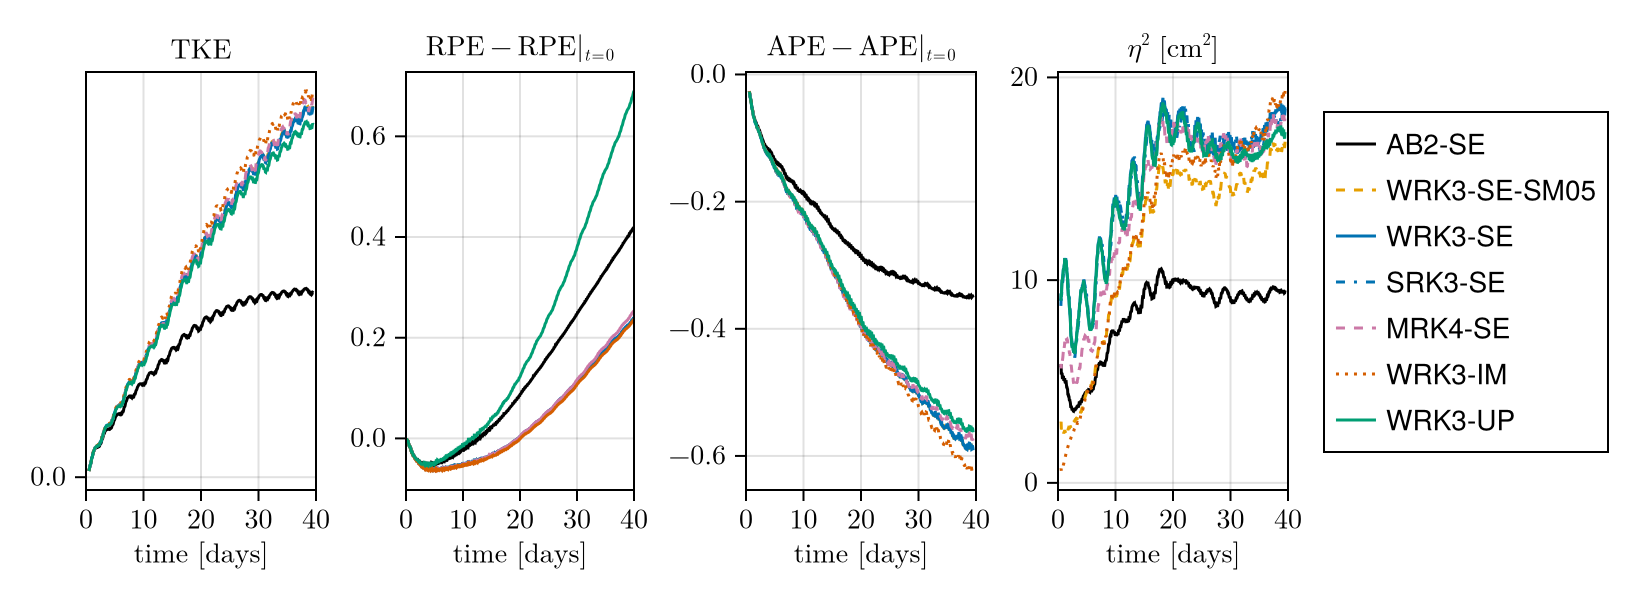

CairoMakie.Screen{PDF}


In [9]:
fig = Figure(size = (820, 300))
ax1 = Axis(fig[1, 1], title=L"\text{TKE}",                    xlabel=L"\text{time [days]}", xticks=ticks([0, 10, 20, 30, 40]), yticks=ticks([0.00, 0.02, 0.04]))
ax2 = Axis(fig[1, 2], title=L"\text{RPE}-\text{RPE}|_{t=0}",  xlabel=L"\text{time [days]}", xticks=ticks([0, 10, 20, 30, 40]), yticks=ticks([0.00, 0.2, 0.4, 0.6]))
ax3 = Axis(fig[1, 3], title=L"\text{APE}-\text{APE}|_{t=0}",  xlabel=L"\text{time [days]}", xticks=ticks([0, 10, 20, 30, 40]), yticks=ticks([0.00, -0.2, -0.4, -0.6, -0.8]))
ax4 = Axis(fig[1, 4], title=L"\eta^2 \text{ [cm}^2\text{]}",  xlabel=L"\text{time [days]}", xticks=ticks([0, 10, 20, 30, 40]), yticks=ticks([0, 10, 20, 30, 40]))
times = cases[1][:Abx].times ./ 86400

for (i, c) in enumerate(cases)
    # lines!(ax1, times, c[:KE] .- c[:MKE], color = (colors[i], 0.05))
    lines!(ax1, running_mean(times, 12), running_mean(c[:KE] .- c[:MKE], 12), color = colors[i], label = labels[i], linestyle = linestyles[i])
    lines!(ax2, times[3:end], c[:RPE][3:end] .- c[:RPE][3], color = colors[i])
    # lines!(ax3, times[3:end], -(c[:APE][3:end] .- c[:APE][3]), color = (colors[i], 0.05))
    lines!(ax3, running_mean(times[3:end], 12), -running_mean(c[:APE][3:end] .- c[:APE][3], 12), color = colors[i], label = labels[i], linestyle = linestyles[i])
    # lines!(ax4, times, c[:η2] .* 1e4, color = (colors[i], 0.05))
    lines!(ax4, running_mean(times, 12), running_mean(c[:η2] .* 1e4, 12), color = colors[i], label = labels[i], linestyle = linestyles[i])
end

xlims!(ax1, 0, 40); xlims!(ax2, 0, 40); xlims!(ax3, 0, 40); xlims!(ax4, 0, 40)
Legend(fig[1, 5], ax3)
display(fig)
CairoMakie.save(path * "energetics-internal-tide.pdf", fig)


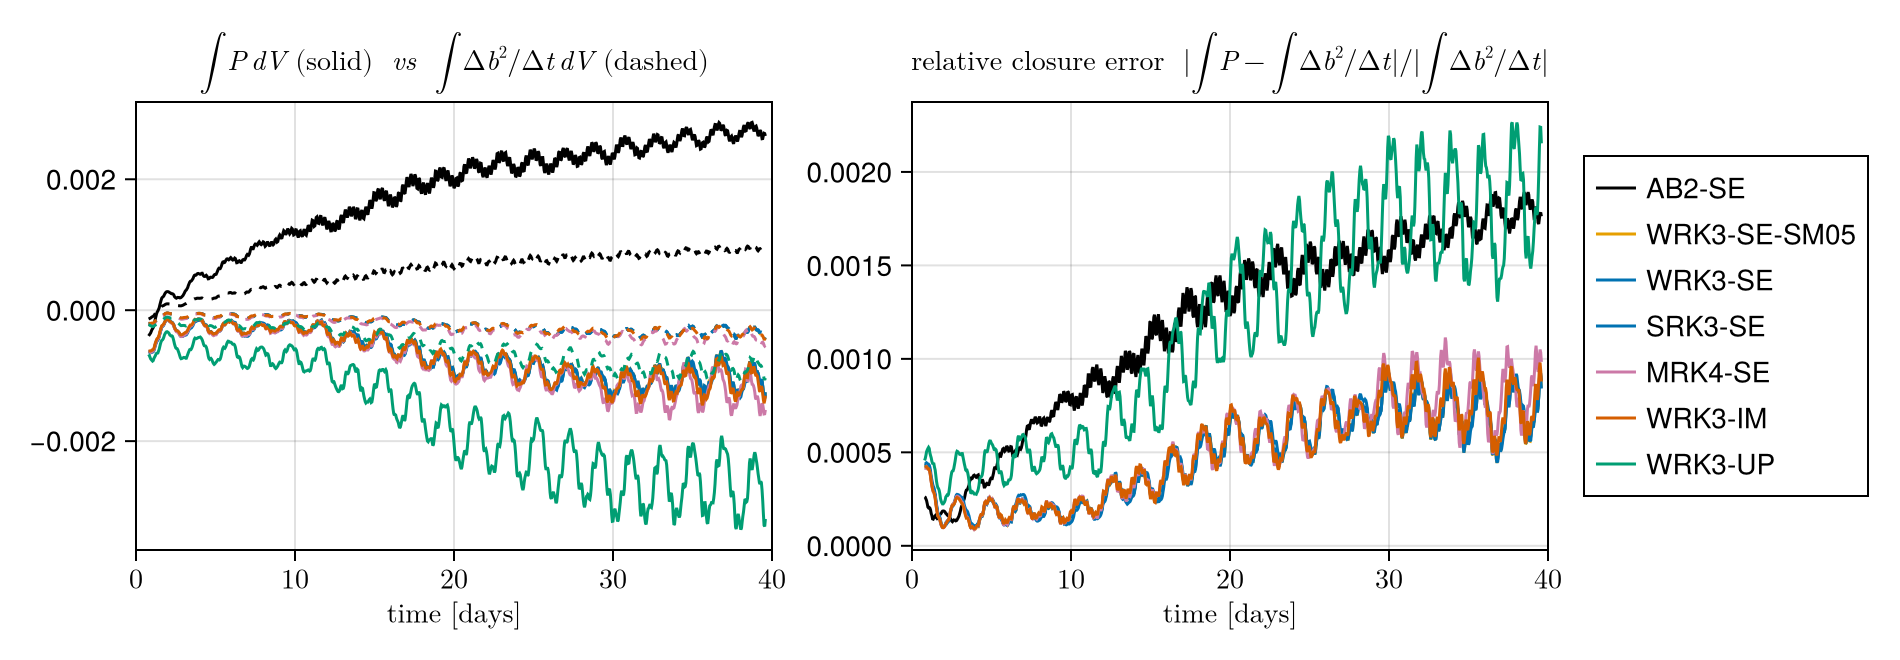

CairoMakie.Screen{IMAGE}


In [10]:
# --- Variance-budget closure check ---
# The numerical dissipation ∫P dV (solid) should equal the actual variance change ∫Δ(b²)/Δt dV
# (dashed) once integrated over the closed domain — IF the diagnostic uses the tracer-advecting
# transport uᵈ (Oceananigans PR #5298). A gap between solid and dashed, or a relative error that
# is not ~round-off, means the budget does not close for that case.
times = cases[1][:Abx].times ./ 86400
mvv   = 10

fig = Figure(size = (950, 330))
ax1 = Axis(fig[1, 1], xlabel = L"\text{time [days]}", xticks = ticks([0, 10, 20, 30, 40]),
           title = L"\int P\,dV \text{ (solid)} \ \ vs \ \ \int \Delta b^2/\Delta t\,dV \text{ (dashed)}")
ax2 = Axis(fig[1, 2], xlabel = L"\text{time [days]}", xticks = ticks([0, 10, 20, 30, 40]), # yscale = log10,
           title = L"\text{relative closure error} \ \ |\int P - \int \Delta b^2/\Delta t| / |\int \Delta b^2/\Delta t|")

for (i, c) in enumerate(cases)
    lines!(ax1, running_mean(times[10:end], mvv), running_mean(c[:∫Pb][10:end],  mvv), color = colors[i], label = labels[i])
    lines!(ax1, running_mean(times[10:end], mvv), running_mean(c[:∫Δb²][10:end], mvv), color = colors[i], linestyle = :dash)
    relerr = abs.(c[:∫Pb] .- c[:∫Δb²]) 
    lines!(ax2, running_mean(times[10:end], mvv), running_mean(relerr[10:end], mvv), color = colors[i])
end
xlims!(ax1, 0, 40); xlims!(ax2, 0, 40)
Legend(fig[1, 3], ax1)
display(fig)


## Temporal-resolution test

WRK3-SE and SRK3-SE differ by a factor of eight in the rectified bottom flow at the full time step. Repeating both at `Δt/4`, with the substep count scaled so the barotropic Courant number is unchanged, separates a converged feature from one still limited by the temporal resolution of the baroclinic step.

In [11]:
# ══ Temporal-resolution test: the rectified bottom flow (section 5.1) ═════════════════════════════
# WRK3-SE and SRK3-SE at the full step, Δt/4 and Δt/8, with the substep count reduced in proportion so the
# barotropic Courant number is unchanged. Colour is the composition, dash is the reduced step: solid and
# dashed lying on top of each other means converged in time. The averaging kernel keeps its moments
# exactly at 64, 16 and 8 substeps, so a degraded filter is not confounding the comparison.

refined = [(; label = "WRK3-SE", timestepper = "SplitRungeKutta3",    tag = "dt4"),
           (; label = "SRK3-SE", timestepper = "SSPRungeKutta3",      tag = "dt4"),
           (; label = "MRK4-SE", timestepper = "ModifiedRungeKutta4", tag = "dt4"),
           (; label = "WRK3-SE", timestepper = "SplitRungeKutta3",    tag = "dt8"),
           (; label = "SRK3-SE", timestepper = "SSPRungeKutta3",      tag = "dt8"),
           (; label = "MRK4-SE", timestepper = "ModifiedRungeKutta4", tag = "dt8")]

cases_refined = [@suppress TimestepperTestCases.load_internal_tide(folder, v.timestepper, v.label * "-" * v.tag) for v in refined]

"Time-mean over the last `days` of the x-averaged u', in m/s: the tide cancels, the rectified flow survives."
function rectified_profile(c; days = 10)
    t  = c[:u].times ./ 86400
    i0 = findfirst(≥(t[end] - days), t)
    acc = zeros(size(interior(c[:u][1]), 3)); n = 0
    for it in i0:length(t)
        u = interior(c[:u][it]) ./ interior(c[:VFCC][it])     # z-star: volumes vary in time
        acc .+= vec(mean(u .- mean(u), dims = 1)); n += 1
    end
    return acc ./ n
end

rectified_profile

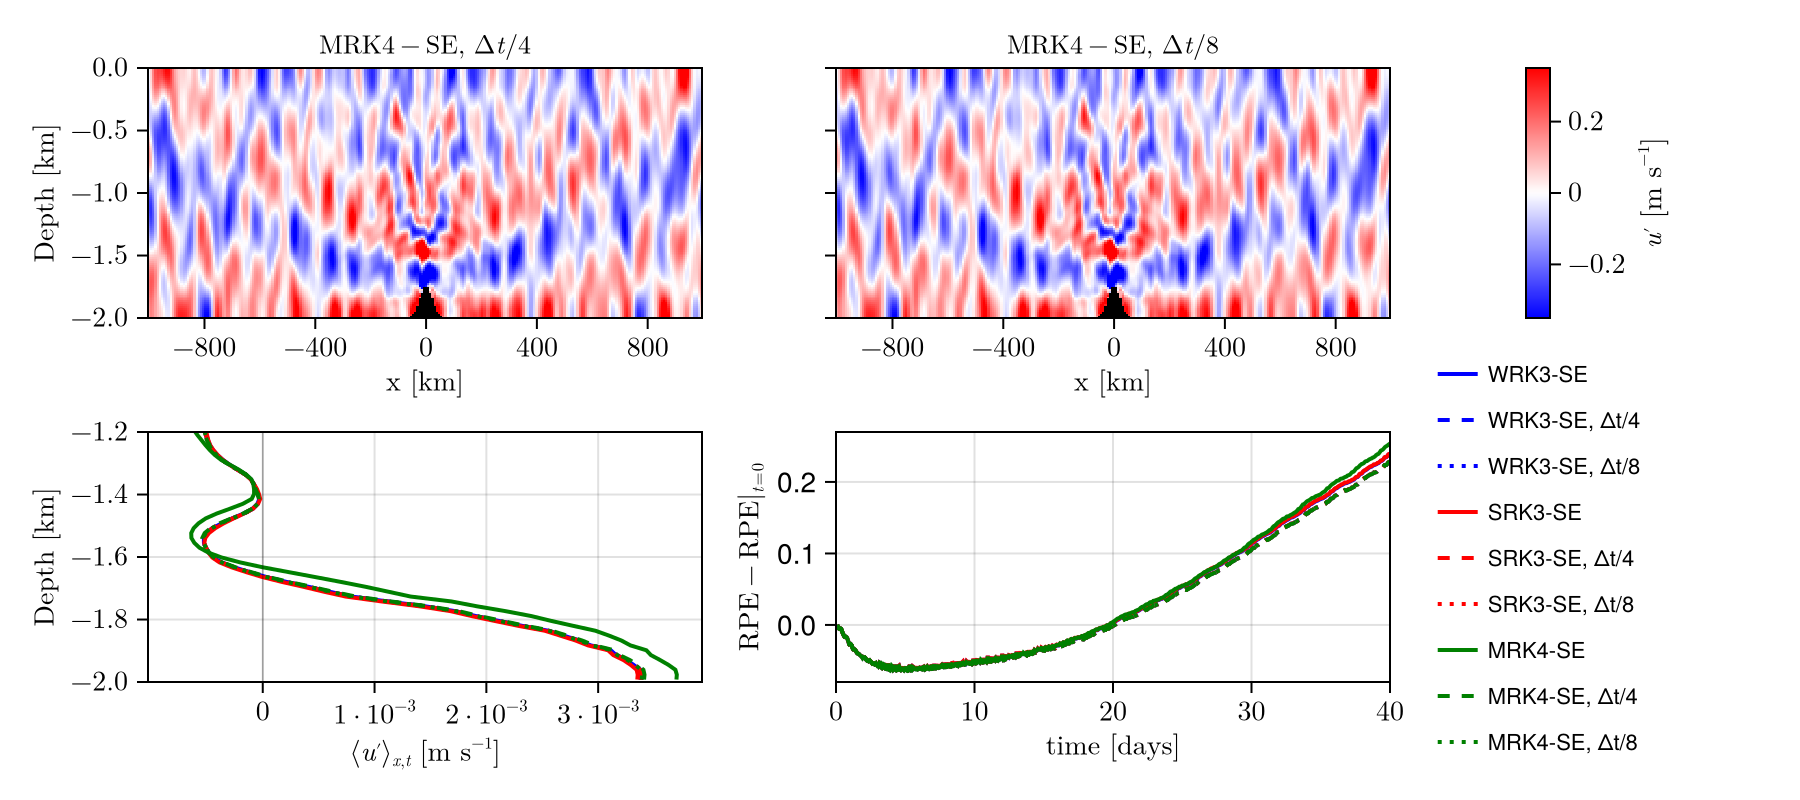

CairoMakie.Screen{PDF}


In [13]:
# ══ Temporal-resolution test: rectified flow and irreversible mixing ══════════════════════════════
zu_km = zu ./ 1000
iW = findfirst(v -> v.label == "WRK3-SE", variants)
iS = findfirst(v -> v.label == "SRK3-SE", variants)
iM = findfirst(v -> v.label == "MRK4-SE", variants)

curves = [("WRK3-SE",       cases[iW],        :solid, :blue),
          ("WRK3-SE, Δt/4", cases_refined[1], :dash,  :blue),
          ("WRK3-SE, Δt/8", cases_refined[4], :dot,   :blue),
          ("SRK3-SE",       cases[iS],        :solid, :red),
          ("SRK3-SE, Δt/4", cases_refined[2], :dash,  :red),
          ("SRK3-SE, Δt/8", cases_refined[5], :dot,   :red),
          ("MRK4-SE",       cases[iM],        :solid, :green),
          ("MRK4-SE, Δt/4", cases_refined[3], :dash,  :green),
          ("MRK4-SE, Δt/8", cases_refined[6], :dot,   :green)]

snap_uprime(c) = Field(c[:u][end] / c[:VFCC][end] - mean(c[:u][end] / c[:VFCC][end]))

"Time-mean of u' over x and t: the tide cancels, the rectified flow survives."
function rectified_profile(c; days = 10)
    t  = c[:u].times ./ 86400
    i0 = findfirst(≥(t[end] - days), t)
    acc = zeros(size(interior(c[:u][1]), 3)); n = 0
    for it in i0:length(t)
        u = interior(c[:u][it]) ./ interior(c[:VFCC][it])
        acc .+= vec(mean(u .- mean(u), dims = 1)); n += 1
    end
    return acc ./ n
end

xkm    = ([-800, -400, 0, 400, 800] .* 1000, latexstring.(string.([-800, -400, 0, 400, 800])))
uticks = ([0.0, 1e-3, 2e-3, 3e-3], [L"0", L"1\cdot 10^{-3}", L"2\cdot 10^{-3}", L"3\cdot 10^{-3}"])
tticks = ticks([0, 10, 20, 30, 40])

fig = Figure(size = (900, 400), fontsize = 14)

# ── top: instantaneous u' of SRK3-SE, own step and refined ────────────────────────────────────────
hm = nothing
for (col, (ttl, c)) in enumerate((L"\text{MRK4-SE, } \Delta t/4" => cases_refined[3],
                                  L"\text{MRK4-SE, } \Delta t/8" => cases_refined[6]))
    ax = Axis(fig[1, col]; title = ttl, titlesize = 13,
              xlabel = L"\text{x [km]}", xticks = xkm,
              ylabel = col == 1 ? L"\text{Depth [km]}" : "",
              yticks = col == 1 ? ticks([-2.0, -1.5, -1.0, -0.5, 0.0]) :
                                  ([-2.0, -1.5, -1.0, -0.5, 0.0], ["", "", "", "", ""]))

    global hm = heatmap!(ax, xu, zu_km, interior(snap_uprime(c), :, 1, :) .+ bu[:, 1, :];
                         colormap = :bwr, colorrange = (-0.35, 0.35),
                         nan_color = :black, rasterize = 2)
    ylims!(ax, -2, 0)                       # km, matching zu_km
end
Colorbar(fig[1, 3], hm; label = L"u^\prime \text{ [m s}^{-1}\text{]}",
         ticks = ([-0.2, 0.0, 0.2], [L"-0.2", L"0", L"0.2"]))

# ── bottom left: the rectified profiles ───────────────────────────────────────────────────────────
axu = Axis(fig[2, 1]; xlabel = L"\langle u^\prime \rangle_{x,t} \text{ [m s}^{-1}\text{]}",
           ylabel = L"\text{Depth [km]}", xticks = uticks,
           yticks = ticks([-2.0, -1.8, -1.6, -1.4, -1.2]))

for (lab, c, ls, clr) in curves
    lines!(axu, rectified_profile(c), zu_km; color = clr, linestyle = ls, linewidth = 2, label = lab)
end
vlines!(axu, 0; color = (:black, 0.3), linewidth = 0.8)
ylims!(axu, -2, -1.2)

# ── bottom right: the RPE trajectories ────────────────────────────────────────────────────────────
axr = Axis(fig[2, 2]; xlabel = L"\text{time [days]}", xticks = tticks,
           ylabel = L"\text{RPE} - \text{RPE}|_{t=0}")

for (lab, c, ls, clr) in curves
    t = c[:RPE] isa AbstractVector ? (c[:Abx].times ./ 86400) : nothing
    lines!(axr, t[3:end], c[:RPE][3:end] .- c[:RPE][3];
           color = clr, linestyle = ls, linewidth = 2, label = lab)
end
xlims!(axr, 0, 40)
Legend(fig[2, 3], axr; framevisible = false, labelsize = 11)

display(current_figure())
CairoMakie.save(path * "rectified-internal-tide.pdf", fig)